In [20]:
import pickle 
import pandas as pd
import sys
import os
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)
parent_dir = os.path.dirname(parent_dir)
sys.path.append(f'{parent_dir}/VEBGLM/src')
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pickle

import matplotlib.pyplot as plt 
import seaborn as sns

In [21]:

pd.set_option('display.max_rows', None)
with open(f'{current_dir}/results/simu_metric_n.pkl', 'rb') as f:
    res = pickle.load(f)
results_df = pd.DataFrame(res)

In [22]:
res = results_df.groupby(['model', 'metric','n','p','r','s','beta_dist']).mean().reset_index()
# res[(res['metric']=='recall_score') ]
# res[(res['metric']=='roc_auc_score') & (res['r']==0.99)]

In [23]:
acc_df = res[(res['metric']=='roc_auc_score')]
acc_df.head()

,model,metric,n,p,r,s,beta_dist,rep,seed,score,run_time
40,L0Learn,roc_auc_score,100,1000,0.0,20,normal,9.5,9.5,0.673398,5.081303
41,L0Learn,roc_auc_score,200,1000,0.0,20,normal,9.5,29.5,0.839794,10.182028
42,L0Learn,roc_auc_score,300,1000,0.0,20,normal,9.5,49.5,0.889391,17.034263
43,L0Learn,roc_auc_score,500,1000,0.0,20,normal,9.5,69.5,0.923705,37.065507
44,L0Learn,roc_auc_score,750,1000,0.0,20,normal,9.5,89.5,0.939191,69.038016


In [24]:
lwd = 0.9
mks = 6
alpha=0.8
model_mapping = {
    'L0Learn': {'color': 'green', 'linestyle': ':', 'marker': 'X', 'linewidth': lwd,'alpha': alpha, 'markersize': mks},
    'SCAD': {'color': 'brown', 'linestyle': '--', 'marker': '^', 'linewidth': lwd,'alpha': alpha, 'markersize': mks},
    'MCP': {'color': 'salmon', 'linestyle': '-', 'marker': 's', 'linewidth': lwd,'alpha': alpha, 'markersize': mks},
    'varbvs': {'color': 'olive', 'linestyle': '--', 'marker': 'P', 'linewidth': lwd,'alpha': alpha, 'markersize': mks},
    'elasticnet': {'color': 'orangered', 'linestyle': '--', 'marker': 'D', 'linewidth': lwd,'alpha': alpha, 'markersize': mks},
    'lasso': {'color': 'violet', 'linestyle': '-', 'marker': 'p', 'linewidth': lwd,'alpha': alpha, 'markersize': mks},
    'VEBGLM-ash': {'color': 'pink', 'linestyle': '-', 'marker': 'd', 'linewidth': lwd,'alpha': alpha, 'markersize': mks},
    'VEBGLM-point_laplace': {'color': 'orange', 'linestyle': '-', 'marker': 'v', 'linewidth': lwd,'alpha': alpha, 'markersize': mks},
    'VEBGLM-point_normal': {'color': 'maroon', 'linestyle': '-', 'marker': 'o', 'linewidth': 1.5,'alpha': alpha, 'markersize': 6},
    'ridge': {'color': 'purple', 'linestyle': '-', 'marker': 'v', 'linewidth': lwd,'alpha': alpha, 'markersize': mks},
    'sparsevb': {'color': 'grey', 'linestyle': '-', 'marker': 'D', 'linewidth': lwd,'alpha': alpha, 'markersize': mks}
}
legend_names = {
    'VEBGLM-ash': 'EBGLM-ash',
    'VEBGLM-point_normal': 'EBGLM-pn',
    'VEBGLM-point_laplace': 'EBGLM-pl',
    'L0Learn': 'L0Learn',
    'MCP': 'mcp',
    'SCAD': 'scad',
    'ridge': 'ridge',
    'sparsevb': 'sparsevb',
    'lasso': 'lasso',
    'varbvs': 'varbvs',
    'elasticnet': 'elasticnet',
}
fig_size = (7,6)

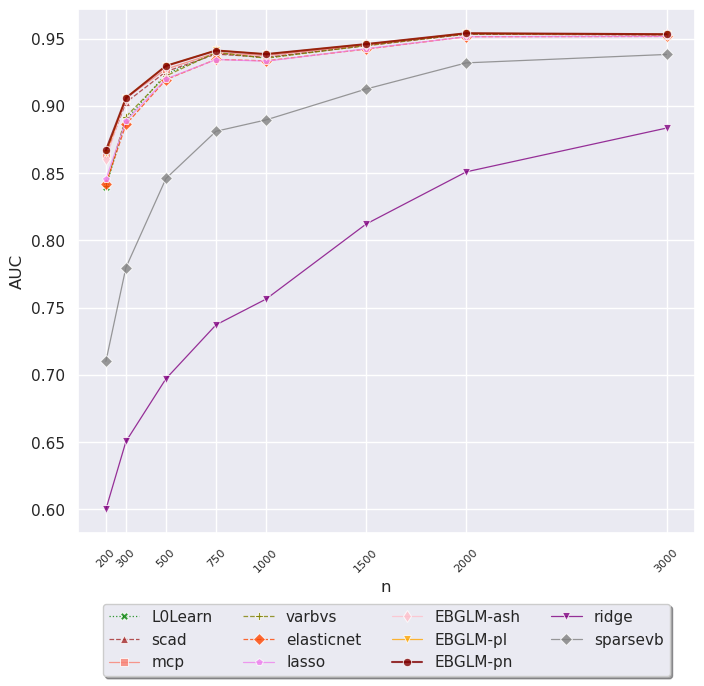

In [28]:


# Set the style and figure size
sns.set(style="darkgrid")
plt.figure(figsize=fig_size)

# Create a line plot for each model using custom legend names
for model, props in model_mapping.items():
    subset = acc_df[acc_df['model'] == model]
    plt.plot(subset['n'], subset['score'], label=legend_names[model], markeredgecolor='white', markeredgewidth=0.7,**props)

# Adjustments and decorations
plt.xticks(acc_df['n'].unique(), rotation=45, fontsize=8)
# plt.legend()
plt.tight_layout()
plt.xlabel('n')
plt.ylabel('AUC')
# Save and show the plot
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), fancybox=True, shadow=True, ncol=4)
plt.savefig('plot/roc_auc_score_n_appendix.pdf', bbox_inches='tight')
plt.show()

In [29]:
pd.set_option('display.max_rows', None)
with open(f'{current_dir}/results/simu_metric_p_final.pkl', 'rb') as f:
    res = pickle.load(f)
results_df = pd.DataFrame(res)
res = results_df.groupby(['model', 'metric','n','p','r','s','beta_dist']).mean().reset_index()
acc_df = res[(res['metric']=='roc_auc_score')]

/tmp/ipykernel_3860100/1731100404.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  acc_df['p'] = acc_df['p'].astype('str')


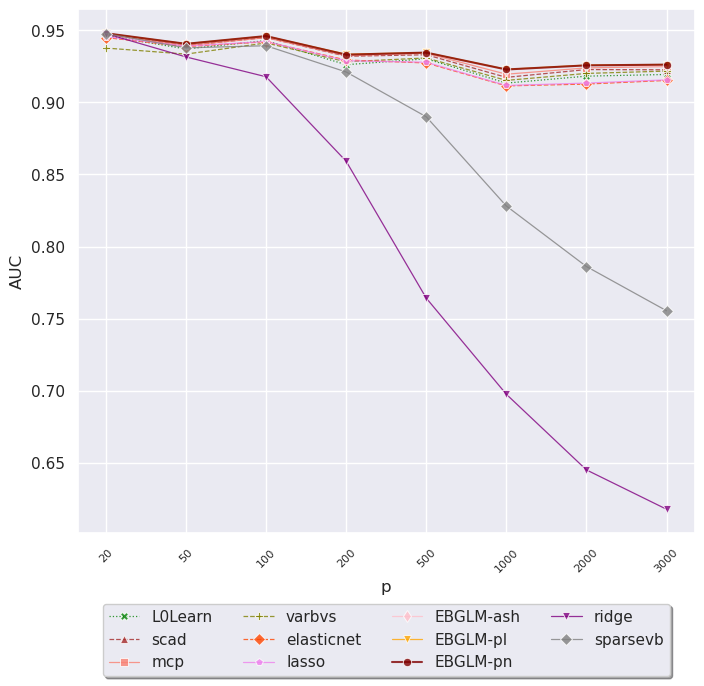

In [31]:

acc_df['p'] = acc_df['p'].astype('str')
# Set the style and figure size
sns.set(style="darkgrid")
plt.figure(figsize=fig_size)

# Create a line plot for each model using custom legend names
for model, props in model_mapping.items():
    subset = acc_df[acc_df['model'] == model]
    plt.plot(subset['p'], subset['score'], label=legend_names[model], markeredgecolor='white', markeredgewidth=0.7,**props)

# Adjustments and decorations
plt.xticks(acc_df['p'].unique(), rotation=45, fontsize=8)
# plt.legend()
plt.tight_layout()
plt.xlabel('p')
plt.ylabel('AUC')
# Save and show the plot
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), fancybox=True, shadow=True, ncol=4)
plt.savefig('plot/roc_auc_score_p_appendix.pdf', bbox_inches='tight')
plt.show()

In [32]:
pd.set_option('display.max_rows', None)
with open(f'{current_dir}/results/simu_metric_rho_final.pkl', 'rb') as f:
    res = pickle.load(f)
results_df = pd.DataFrame(res)
res = results_df.groupby(['model', 'metric','n','p','r','s','beta_dist']).mean().reset_index()
acc_df = res[(res['metric']=='roc_auc_score')]

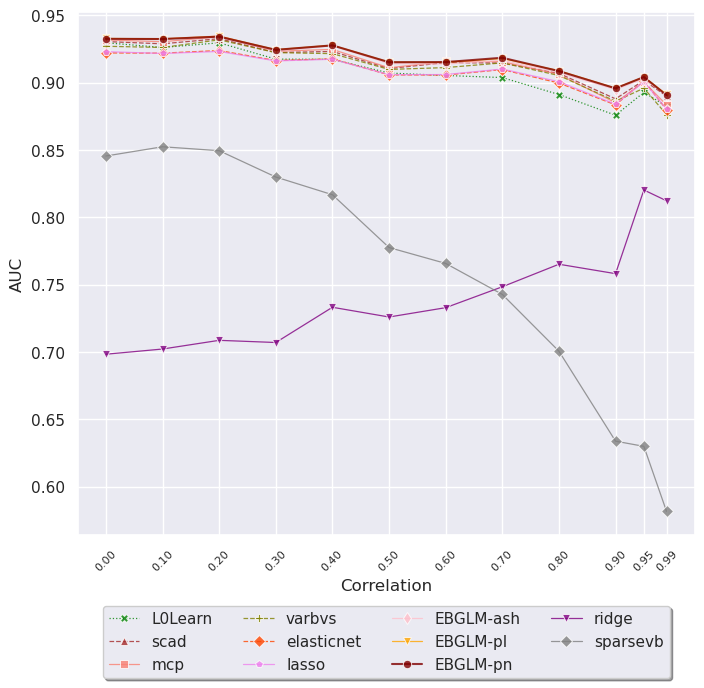

In [34]:
# acc_df  = acc_df[~acc_df['model'].isin(['ridge', 'sparsevb','VEBGLM-ash','VEBGLM-point_laplace','MCP'])]


sns.set(style="darkgrid")
plt.figure(figsize=fig_size)

# Create a line plot for each model using custom legend names
for model, props in model_mapping.items():
    subset = acc_df[acc_df['model'] == model]
    plt.plot(subset['r'], subset['score'], label=legend_names[model], markeredgecolor='white', markeredgewidth=0.7,**props)

# Adjustments and decorations
plt.xticks(acc_df['r'].unique(), rotation=45, fontsize=8)
# plt.legend()
plt.tight_layout()
plt.xlabel('Correlation')
plt.ylabel('AUC')
# Save and show the plot
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), fancybox=True, shadow=True, ncol=4)
plt.savefig('plot/roc_auc_score_r_appendix.pdf', bbox_inches='tight')
plt.show()

In [35]:
pd.set_option('display.max_rows', None)
with open(f'{current_dir}/results/simu_metric_s_final.pkl', 'rb') as f:
    res = pickle.load(f)
results_df = pd.DataFrame(res)
res = results_df.groupby(['model', 'metric','n','p','r','s','beta_dist']).mean().reset_index()
acc_df = res[(res['metric']=='roc_auc_score')]

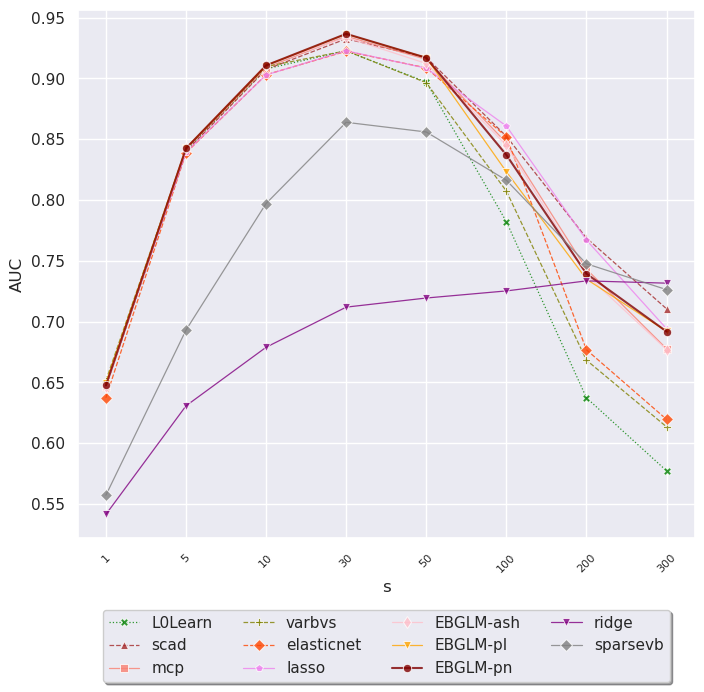

In [36]:

acc_df['s'] = acc_df['s'].astype('str')

sns.set(style="darkgrid")
plt.figure(figsize=fig_size)

# Create a line plot for each model using custom legend names
for model, props in model_mapping.items():
    subset = acc_df[acc_df['model'] == model]
    plt.plot(subset['s'], subset['score'], label=legend_names[model], markeredgecolor='white', markeredgewidth=0.7,**props)

# Adjustments and decorations
plt.xticks(acc_df['s'].unique(), rotation=45, fontsize=8)
# plt.legend()
plt.tight_layout()
plt.xlabel('s')
plt.ylabel('AUC')
# Save and show the plot
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), fancybox=True, shadow=True, ncol=4)
plt.savefig('plot/roc_auc_score_s_appendix.pdf', bbox_inches='tight')
plt.show()

In [14]:
pd.set_option('display.max_rows', None)
with open(f'{current_dir}/results/simu_metric_beta_dist.pkl', 'rb') as f:
    res = pickle.load(f)
results_df = pd.DataFrame(res)
res = results_df.groupby(['model', 'metric','n','p','r','s','beta_dist']).mean().reset_index()
acc_df = res[(res['metric']=='roc_auc_score')]

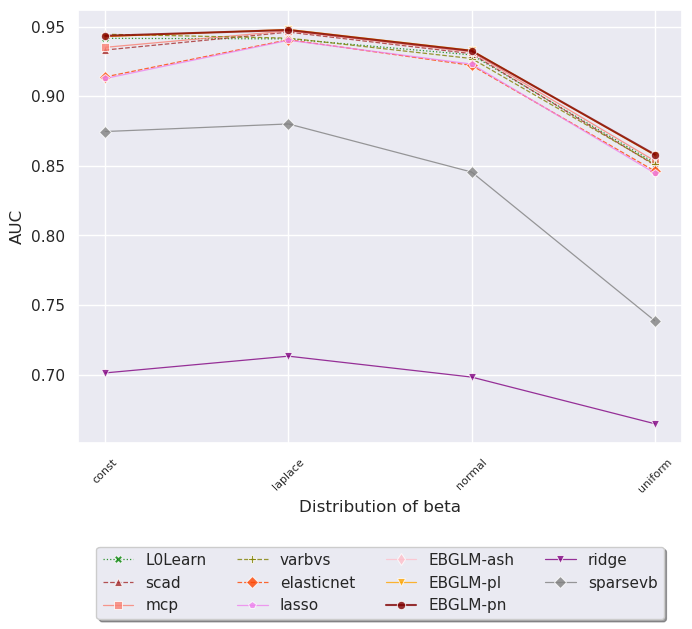

In [19]:


sns.set(style="darkgrid")
plt.figure(figsize=fig_size)

# Create a line plot for each model using custom legend names
for model, props in model_mapping.items():
    subset = acc_df[acc_df['model'] == model]
    plt.plot(subset['beta_dist'], subset['score'], label=legend_names[model], markeredgecolor='white', markeredgewidth=0.7,**props)

# Adjustments and decorations
plt.xticks(acc_df['beta_dist'].unique(), rotation=45, fontsize=8)

# Adjusting the plot to make room for the legend below it
plt.subplots_adjust(bottom=0.5)

# Adding the legend below the plot
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.22), fancybox=True, shadow=True, ncol=4)


plt.tight_layout()
plt.xlabel('Distribution of beta')
plt.ylabel('AUC')
# Save and show the plot
plt.savefig('plot/roc_auc_score_beta_dist_appendix.pdf', bbox_inches='tight')
plt.show()